# 03 — Where Is Participation Low and Why? Geographic Analysis

NSE investor data (2026) × Census 2011 state-level covariates.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

DATA = Path("..") / "data"
SEBI = DATA / "sebi"

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})


## 1. Zone-Level Instrument Distribution (File 17)

instrument  Commodity Futures  Debentures  Derivatives  Equities  Mutual Funds
zone                                                                          
East                      163          37            0       143           633
North                     143         218          212       804           859
South                      19          88            5       157           212
West                       44         913          294      1837          1832


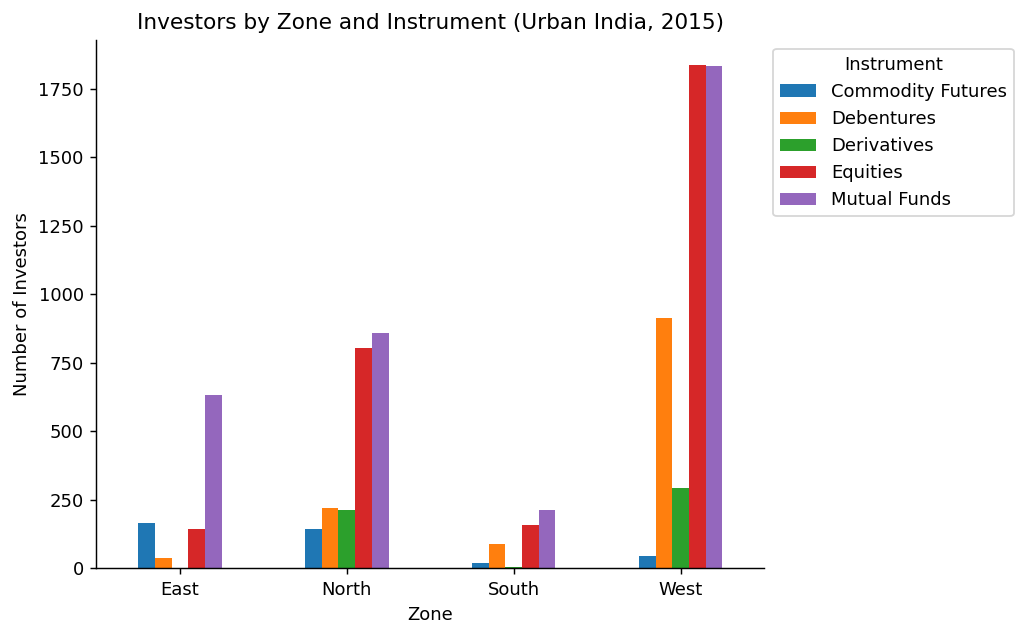

In [2]:
zone = pd.read_csv(SEBI / "17_urban_zone_investors_and_instruments_used.csv")
zone.columns = ["country", "year", "instrument", "zone", "n_investors"]

pivot_z = zone.pivot_table(index="zone", columns="instrument", values="n_investors", aggfunc="sum")
print(pivot_z)

fig, ax = plt.subplots(figsize=(8, 5))
pivot_z.plot(kind="bar", ax=ax)
ax.set_xlabel("Zone")
ax.set_ylabel("Number of Investors")
ax.set_title("Investors by Zone and Instrument (Urban India, 2015)")
ax.legend(title="Instrument", bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. State-Level Data — investors_per_lakh

In [3]:
sl = pd.read_csv(DATA / "state_layer.csv")

print(f"States: {len(sl)}")
print(sl[["state_name", "investors_per_lakh", "per_capita_income_2011",
          "literate_persons_2011", "graduate_above_2011", "urban_population",
          "pop_per_sqkm"]].sort_values("investors_per_lakh", ascending=False).to_string(index=False))


States: 35
          state_name  investors_per_lakh  per_capita_income_2011  literate_persons_2011  graduate_above_2011  urban_population  pop_per_sqkm
               Delhi             65482.5                  185001               12737767              2757844          16368899       11320.3
          Chandigarh             49835.5                  158967                 805438               194453           1026459        9258.3
         Maharashtra             38467.8                   99597               81554290              8639081          50818259         365.2
             Gujarat             36570.9                   87481               41093358              3174158          25745083         308.0
                 Goa             34403.8                  259444                1165487               146828            906814         394.0
             Haryana             32871.7                  106085               16598988              1877085           8842103         573.4
Da

## 3. Top and Bottom States

Top 5:
 state_name  investors_per_lakh
      Delhi             65482.5
 Chandigarh             49835.5
Maharashtra             38467.8
    Gujarat             36570.9
        Goa             34403.8

Bottom 5:
       state_name  investors_per_lakh
          Mizoram              5081.3
        Meghalaya              5274.8
         Nagaland              6437.1
      Lakshadweep              8338.4
Arunachal Pradesh              8377.2


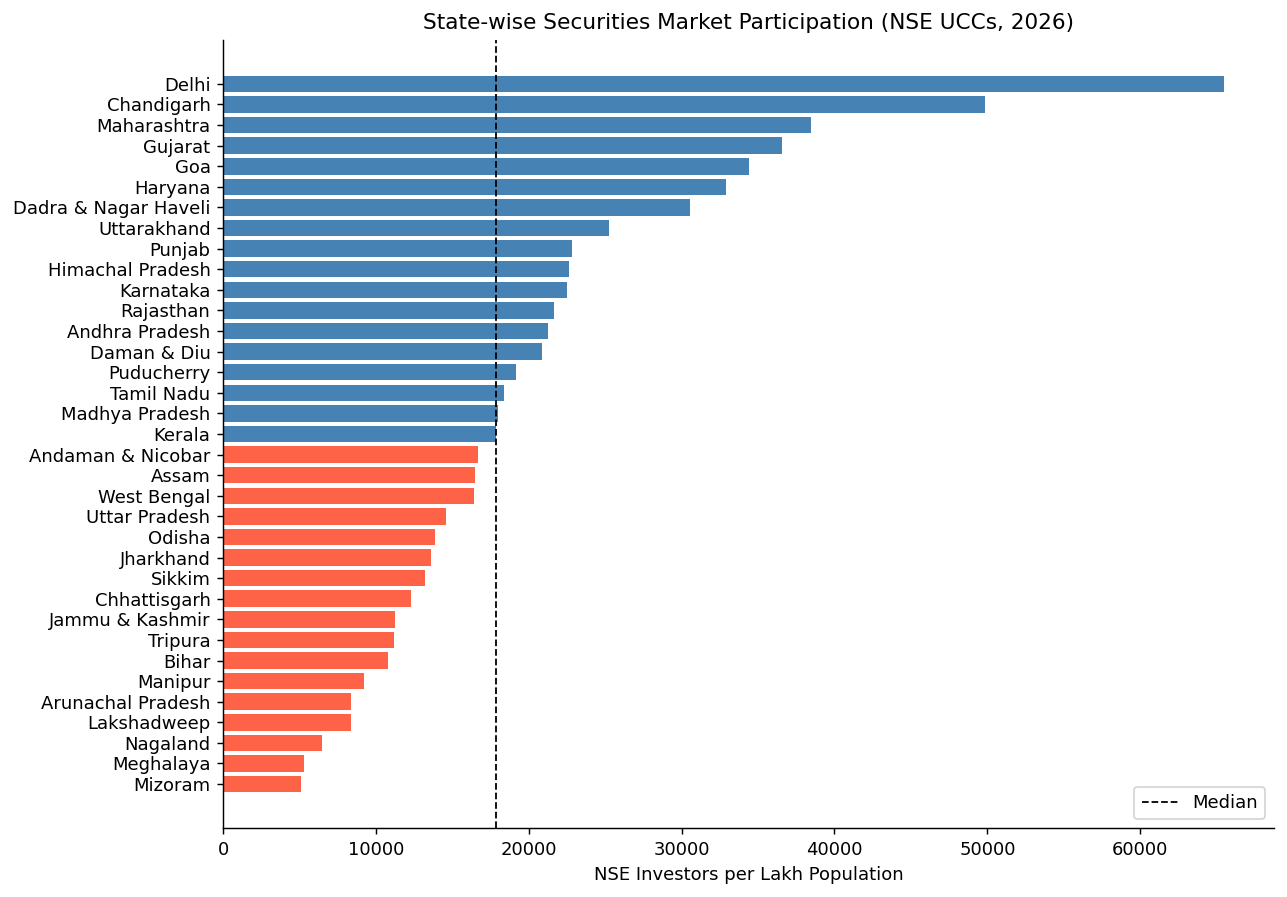

In [4]:
top5    = sl.nlargest(5,  "investors_per_lakh")[["state_name", "investors_per_lakh"]]
bottom5 = sl.nsmallest(5, "investors_per_lakh")[["state_name", "investors_per_lakh"]]

print("Top 5:")
print(top5.to_string(index=False))
print("\nBottom 5:")
print(bottom5.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
sl_sorted = sl.sort_values("investors_per_lakh")
colors = ["tomato" if v < sl["investors_per_lakh"].median() else "steelblue"
          for v in sl_sorted["investors_per_lakh"]]
ax.barh(sl_sorted["state_name"], sl_sorted["investors_per_lakh"], color=colors)
ax.axvline(sl["investors_per_lakh"].median(), color="black", linestyle="--", linewidth=1, label="Median")
ax.set_xlabel("NSE Investors per Lakh Population")
ax.set_title("State-wise Securities Market Participation (NSE UCCs, 2026)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Scatter Plots — Structural Correlates

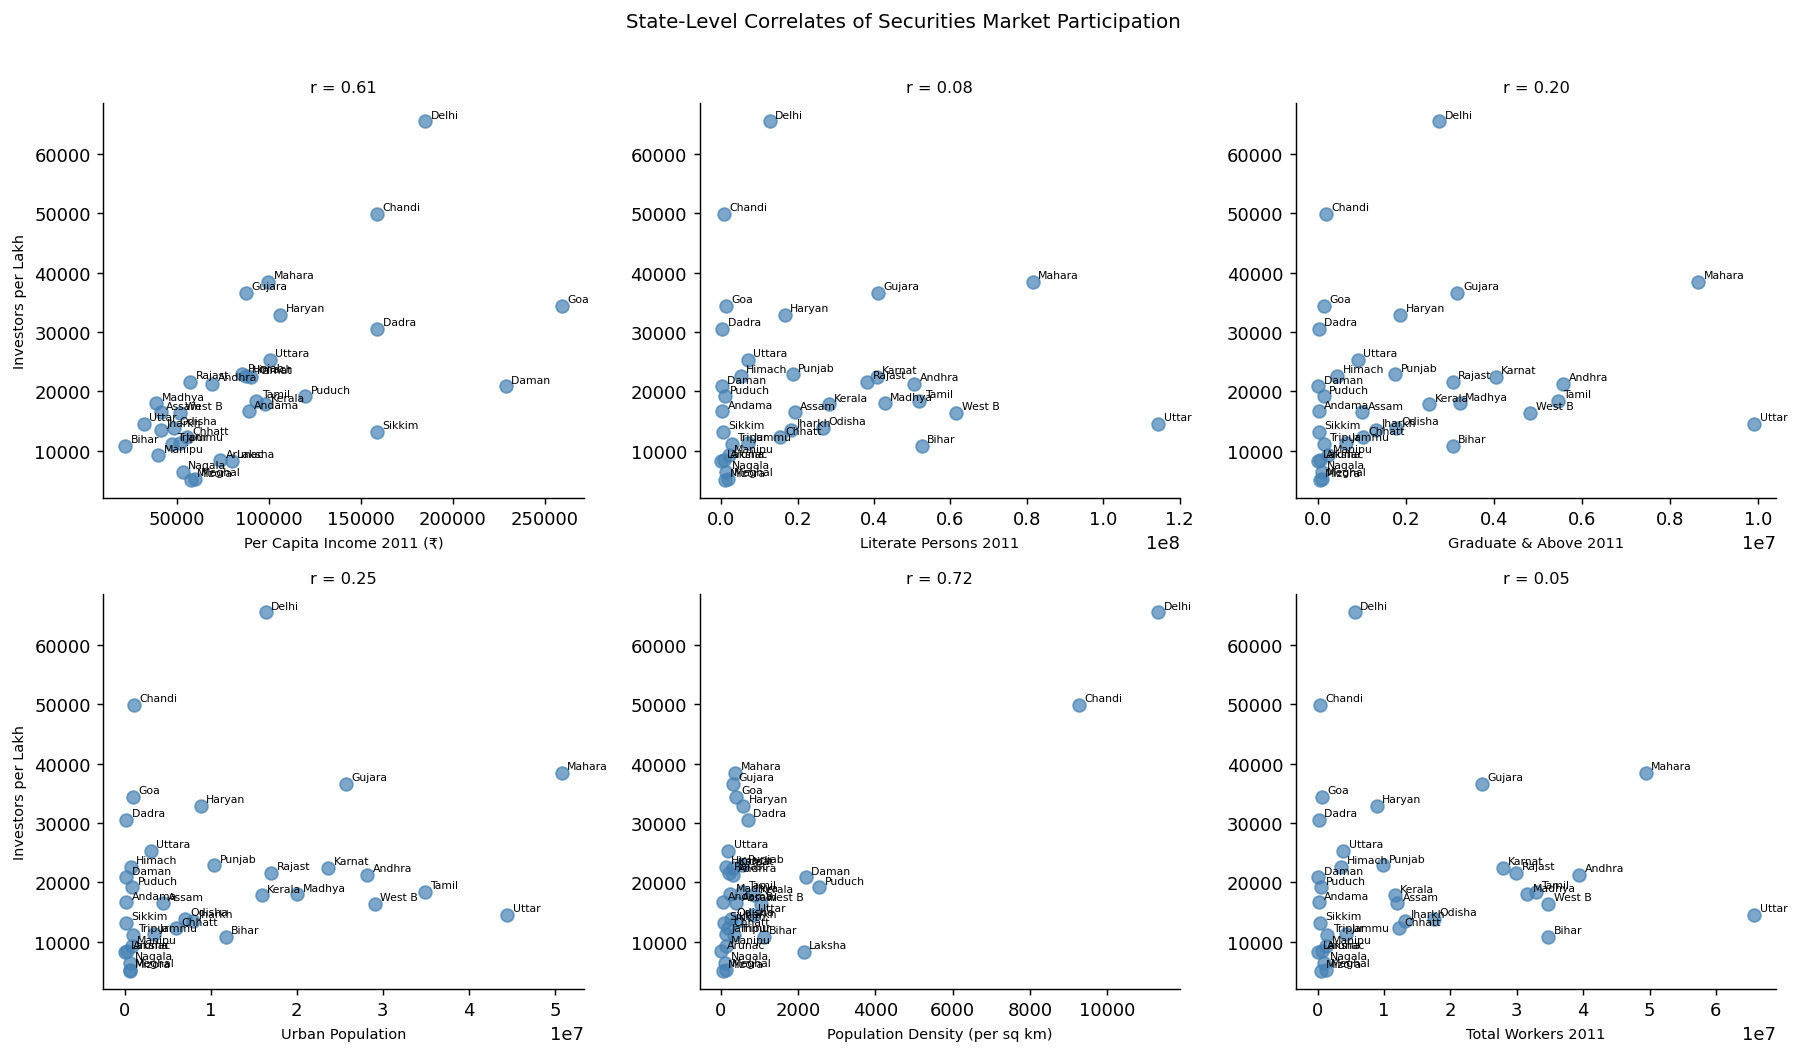

In [5]:
pairs = [
    ("per_capita_income_2011",  "Per Capita Income 2011 (₹)"),
    ("literate_persons_2011",   "Literate Persons 2011"),
    ("graduate_above_2011",     "Graduate & Above 2011"),
    ("urban_population",        "Urban Population"),
    ("pop_per_sqkm",            "Population Density (per sq km)"),
    ("total_workers_2011",      "Total Workers 2011"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, pairs):
    clean = sl[["state_name", "investors_per_lakh", col]].dropna()
    ax.scatter(clean[col], clean["investors_per_lakh"], s=50, color="steelblue", alpha=0.7)
    for _, row in clean.iterrows():
        ax.annotate(row["state_name"][:6], (row[col], row["investors_per_lakh"]),
                    textcoords="offset points", xytext=(3, 2), fontsize=6)
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel("Investors per Lakh" if ax is axes[0] or ax is axes[3] else "", fontsize=8)
    corr = clean[[col, "investors_per_lakh"]].corr().iloc[0, 1]
    ax.set_title(f"r = {corr:.2f}", fontsize=9)

plt.suptitle("State-Level Correlates of Securities Market Participation", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 5. OLS Regression — investors_per_lakh ~ structural covariates

In [6]:
PREDICTORS = [
    "per_capita_income_2011",
    "literate_persons_2011",
    "graduate_above_2011",
    "total_workers_2011",
    "permanent_houses_2001",
    "urban_population",
    "pop_per_sqkm",
    "total_towns",
]

cols = ["investors_per_lakh"] + PREDICTORS
clean = sl[cols].dropna()

X = sm.add_constant(clean[PREDICTORS])
y = clean["investors_per_lakh"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     investors_per_lakh   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     14.77
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           6.92e-08
Time:                        00:36:10   Log-Likelihood:                -350.35
No. Observations:                  35   AIC:                             718.7
Df Residuals:                      26   BIC:                             732.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   5337

## 6. Bivariate OLS — each predictor alone

In [7]:
print(f"{'Predictor':<30} {'Coef':>12} {'p':>8} {'R²':>8}")
print("-" * 62)
for pred in PREDICTORS:
    sub = sl[["investors_per_lakh", pred]].dropna()
    res = sm.OLS(sub["investors_per_lakh"], sm.add_constant(sub[pred])).fit()
    sig = "**" if res.pvalues[pred] < 0.05 else ("*" if res.pvalues[pred] < 0.1 else "")
    print(f"{pred:<30} {res.params[pred]:>12.4f} {res.pvalues[pred]:>8.3f} {res.rsquared:>8.3f}  {sig}")


Predictor                              Coef        p       R²
--------------------------------------------------------------
per_capita_income_2011               0.1413    0.000    0.368  **
literate_persons_2011                0.0000    0.664    0.006  
graduate_above_2011                  0.0010    0.251    0.040  
total_workers_2011                   0.0000    0.757    0.003  
permanent_houses_2001                0.8291    0.782    0.002  
urban_population                     0.0002    0.146    0.063  
pop_per_sqkm                         3.8656    0.000    0.516  **
total_towns                          0.8308    0.918    0.000  
